In [ ]:
!unzip MNIST.zip

Streaming output truncated to the last 5000 lines.
  inflating: MNIST/Train/9/0950.png  
  inflating: MNIST/Train/9/0951.png  
  inflating: MNIST/Train/9/0952.png  
  inflating: MNIST/Train/9/0953.png  
  inflating: MNIST/Train/9/0954.png  
  inflating: MNIST/Train/9/0955.png  
  inflating: MNIST/Train/9/0956.png  
  inflating: MNIST/Train/9/0957.png  
  inflating: MNIST/Train/9/0958.png  
  inflating: MNIST/Train/9/0959.png  
  inflating: MNIST/Train/9/0960.png  
  inflating: MNIST/Train/9/0961.png  
  inflating: MNIST/Train/9/0962.png  
  inflating: MNIST/Train/9/0963.png  
  inflating: MNIST/Train/9/0964.png  
  inflating: MNIST/Train/9/0965.png  
  inflating: MNIST/Train/9/0966.png  
  inflating: MNIST/Train/9/0967.png  
  inflating: MNIST/Train/9/0968.png  
  inflating: MNIST/Train/9/0969.png  
  inflating: MNIST/Train/9/0970.png  
  inflating: MNIST/Train/9/0971.png  
  inflating: MNIST/Train/9/0972.png  
  inflating: MNIST/Train/9/0973.png  
  inflating: MNIST/Train/9/0974.png  

In [ ]:
import time  # For measuring elapsed time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix  # For later exercises, but included here

In [ ]:
# Import from utils.py (upload utils.py to Colab first)
from utils import load_mnist, training_curve_plot

In [ ]:
# Set device for GPU acceleration (Colab T4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Step 1: Load MNIST data (using utils.py function)
# What this does: Loads flattened (784-dim) images and one-hot labels as NumPy arrays.
# We convert to PyTorch tensors and create DataLoaders for mini-batching.
X_train, Y_train, X_test, Y_test = load_mnist()
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(np.argmax(Y_train, axis=1), dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(np.argmax(Y_test, axis=1), dtype=torch.long))

batch_size = 128  # From Assignment 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Step 2: Define the FC network (same as Assignment 1: [784, 128, 64, 10] with ReLU)
# What this does: nn.Sequential stacks layers. nn.Linear is like your matrix multiply + bias.
# ReLU between hidden layers. Output is logits (no softmax—loss handles it).
class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),  # Input to hidden1
            nn.ReLU(),
            nn.Linear(128, 64),   # Hidden1 to hidden2
            nn.ReLU(),
            nn.Linear(64, 10)     # Hidden2 to output (logits for 10 classes)
        )

    def forward(self, x):
        return self.net(x)

model = FCNet().to(device)  # Move to GPU

In [ ]:
# Step 3: Loss and optimizer
# What this does: CrossEntropyLoss computes Eq. 2 (cross-entropy on logits, averaged over batch).
# SGD optimizer (plain, no momentum for simplicity; matches Assignment 1's mini-batch GD).
criterion = nn.CrossEntropyLoss()
learning_rate = 0.005  # From your Assignment 1 ReLU net
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
# Step 4: Training loop (as per instructions)
# What this does: Loops over epochs. For each epoch:
# - Train: Process batches, compute loss/acc per batch, update weights, collect for epoch avg.
# - Test: Evaluate full test set for epoch cost/acc.
# Collects lists for plotting. Measures total time.
num_epochs = 50  # From your Assignment 1
train_costs = []
test_costs = []
train_accuracy = []
test_accuracy = []

start_time = time.time()  # Start timer

for epoch in range(num_epochs):
    model.train()  # Training mode
    batch_losses = []
    batch_accs = []

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()  # Clear gradients
        outputs = model(batch_x)  # Forward pass
        loss = criterion(outputs, batch_y)  # Compute loss (Eq. 2 avg over batch)
        loss.backward()  # Backprop
        optimizer.step()  # Update weights

        batch_losses.append(loss.item())  # Collect batch cost

        # Batch accuracy: argmax on logits == true labels
        _, preds = torch.max(outputs, 1)
        acc = (preds == batch_y).float().mean().item()
        batch_accs.append(acc)

    # Epoch train avg
    train_costs.append(np.mean(batch_losses))
    train_accuracy.append(np.mean(batch_accs))

    # Test evaluation
    model.eval()  # Eval mode (no dropout/BN changes here yet)
    test_loss = 0
    test_correct = 0
    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x, test_y = test_x.to(device), test_y.to(device)
            outputs = model(test_x)
            loss = criterion(outputs, test_y)
            test_loss += loss.item() * test_x.size(0)  # Sum losses (weighted by batch size)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == test_y).sum().item()

    test_costs.append(test_loss / len(test_dataset))  # Avg test cost
    test_accuracy.append(test_correct / len(test_dataset))  # Test acc

    print(f"Epoch {epoch+1}/{num_epochs}: Train Cost {train_costs[-1]:.4f}, Train Acc {train_accuracy[-1]:.4f}, Test Cost {test_costs[-1]:.4f}, Test Acc {test_accuracy[-1]:.4f}")

elapsed = time.time() - start_time  # End timer
print(f"Training completed in {elapsed:.2f} seconds")

Epoch 1/50: Train Cost 2.2724, Train Acc 0.1965, Test Cost 2.2196, Test Acc 0.3334
Epoch 2/50: Train Cost 2.0979, Train Acc 0.4506, Test Cost 1.9042, Test Acc 0.5570
Epoch 3/50: Train Cost 1.6014, Train Acc 0.6370, Test Cost 1.2567, Test Acc 0.7176
Epoch 4/50: Train Cost 1.0400, Train Acc 0.7459, Test Cost 0.8488, Test Acc 0.7888
Epoch 5/50: Train Cost 0.7643, Train Acc 0.8012, Test Cost 0.6634, Test Acc 0.8280
Epoch 6/50: Train Cost 0.6225, Train Acc 0.8343, Test Cost 0.5560, Test Acc 0.8493
Epoch 7/50: Train Cost 0.5352, Train Acc 0.8549, Test Cost 0.4860, Test Acc 0.8676
Epoch 8/50: Train Cost 0.4781, Train Acc 0.8680, Test Cost 0.4411, Test Acc 0.8789
Epoch 9/50: Train Cost 0.4391, Train Acc 0.8781, Test Cost 0.4078, Test Acc 0.8855
Epoch 10/50: Train Cost 0.4115, Train Acc 0.8848, Test Cost 0.3840, Test Acc 0.8911
Epoch 11/50: Train Cost 0.3909, Train Acc 0.8900, Test Cost 0.3677, Test Acc 0.8959
Epoch 12/50: Train Cost 0.3748, Train Acc 0.8944, Test Cost 0.3534, Test Acc 0.8975
E

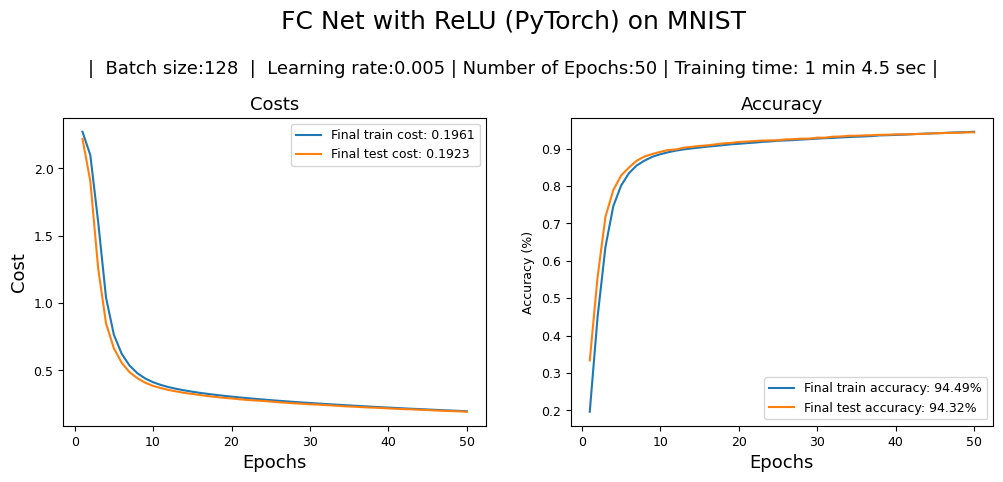

In [ ]:
# Step 5: Plot learning curves (using utils.py function)
# What this does: Calls the provided plot function with the lists and params.
# Shows costs/accs vs. epochs, with final values in legends.
training_curve_plot(
    title="FC Net with ReLU (PyTorch) on MNIST",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    elapsed=elapsed
)

**EXERCISE-2**

In [ ]:
# Reshape data for CNN: [N, 784] → [N, 1, 28, 28]
# In load_mnist, X_train/X_test are (N, 784); reshape them
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_test_cnn  = X_test.reshape(-1, 1, 28, 28)

train_dataset_cnn = TensorDataset(torch.tensor(X_train_cnn, dtype=torch.float32),
                                  torch.tensor(np.argmax(Y_train, axis=1), dtype=torch.long))
test_dataset_cnn  = TensorDataset(torch.tensor(X_test_cnn, dtype=torch.float32),
                                  torch.tensor(np.argmax(Y_test, axis=1), dtype=torch.long))

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=128, shuffle=True)
test_loader_cnn  = DataLoader(test_dataset_cnn, batch_size=128, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F   # for functional relu / max_pool2d

class ExactMNISTCNN(nn.Module):
    def __init__(self):
        super(ExactMNISTCNN, self).__init__()

        # 1. Conv: 8 × 3×3×1, stride=1, padding=1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)

        # 4. Conv: 16 × 3×3×8
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)

        # 7. Conv: 32 × 3×3×16
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        # 10. FC to 10 outputs (logits)
        # After conv3 + ReLU: 32 × 7 × 7 = 1568 features
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # Conv1 → ReLU → MaxPool
        x = self.conv1(x)           # → 8×28×28
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)   # → 8×14×14

        # Conv2 → ReLU → MaxPool
        x = self.conv2(x)           # → 16×14×14
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)   # → 16×7×7

        # Conv3 → ReLU (no pooling after this one)
        x = self.conv3(x)           # → 32×7×7
        x = F.relu(x)

        # Flatten
        x = x.view(x.size(0), -1)   # → batch × 1568

        # FC to 10 logits
        x = self.fc(x)
        return x

# Instantiate and move to device (same as before)
model_cnn = ExactMNISTCNN().to(device)


In [ ]:
print(model_cnn)  # inspect the structure

ExactMNISTCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


In [ ]:
def print_model_parameters(model):
    print("Layer-by-layer trainable parameter counts:\n")
    total_params = 0

    for name, param in model.named_parameters():
        if param.requires_grad:  # only trainable params
            num_params = param.numel()  # total elements in this tensor
            print(f"{name:25s}: {num_params:8,} parameters")
            total_params += num_params

    print(f"\nTotal trainable parameters: {total_params:,}")
    print(f"(This matches the exact specification: ~21,578 params)")

# Call it
print_model_parameters(model_cnn)

Layer-by-layer trainable parameter counts:

conv1.weight             :       72 parameters
conv1.bias               :        8 parameters
conv2.weight             :    1,152 parameters
conv2.bias               :       16 parameters
conv3.weight             :    4,608 parameters
conv3.bias               :       32 parameters
fc.weight                :   15,680 parameters
fc.bias                  :       10 parameters

Total trainable parameters: 21,578
(This matches the exact specification: ~21,578 params)


In [ ]:
# Loss & Optimizer (start with same lr=0.003 or try 0.01)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.005
optimizer = optim.SGD(model_cnn.parameters(), lr=learning_rate)  # added momemtum=0.9  ## or Adam for faster convergence: optim.Adam(..., lr=0.001)

In [ ]:
# Loss & Optimizer (start with same lr=0.003 or try 0.01)
#------------------------------------ADAM----------------------------------------EXERCISE-4---------------------------------------------
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.Adam(params=model_cnn.parameters())  # added momemtum  ## or Adam for faster convergence: optim.Adam(..., lr=0.001)

In [ ]:
num_epochs = 50  # From Assignment 1
train_costs = []
test_costs = []
train_accuracy = []
test_accuracy = []

start_time = time.time()  # Start timer

for epoch in range(num_epochs):
    model_cnn.train()  # Training mode
    batch_losses = []
    batch_accs = []

    for batch_x, batch_y in train_loader_cnn:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()  # Clear gradients
        outputs = model_cnn(batch_x)  # Forward pass
        loss = criterion(outputs, batch_y)  # Compute loss (Eq. 2 avg over batch)
        loss.backward()  # Backprop
        optimizer.step()  # Update weights

        batch_losses.append(loss.item())  # Collect batch cost

        # Batch accuracy: argmax on logits == true labels
        _, preds = torch.max(outputs, 1)
        acc = (preds == batch_y).float().mean().item()
        batch_accs.append(acc)

    # Epoch train avg
    train_costs.append(np.mean(batch_losses))
    train_accuracy.append(np.mean(batch_accs))

    # Test evaluation
    model_cnn.eval()  # Eval mode (no dropout/BN changes here yet)
    test_loss = 0
    test_correct = 0
    with torch.no_grad():
        for test_x, test_y in test_loader_cnn:
            test_x, test_y = test_x.to(device), test_y.to(device)
            outputs = model_cnn(test_x)
            loss = criterion(outputs, test_y)
            test_loss += loss.item() * test_x.size(0)  # Sum losses (weighted by batch size)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == test_y).sum().item()

    test_costs.append(test_loss / len(test_loader_cnn.dataset))  # Avg test cost
    test_accuracy.append(test_correct / len(test_loader_cnn.dataset))  # Test acc

    print(f"Epoch {epoch+1}/{num_epochs}: Train Cost {train_costs[-1]:.4f}, Train Acc {train_accuracy[-1]:.4f}, Test Cost {test_costs[-1]:.4f}, Test Acc {test_accuracy[-1]:.4f}")

elapsed = time.time() - start_time  # End timer
print(f"Training completed in {elapsed:.2f} seconds")

Epoch 1/50: Train Cost 0.3300, Train Acc 0.9029, Test Cost 0.1042, Test Acc 0.9673
Epoch 2/50: Train Cost 0.0921, Train Acc 0.9720, Test Cost 0.0635, Test Acc 0.9808
Epoch 3/50: Train Cost 0.0670, Train Acc 0.9794, Test Cost 0.0482, Test Acc 0.9849
Epoch 4/50: Train Cost 0.0527, Train Acc 0.9833, Test Cost 0.0472, Test Acc 0.9849
Epoch 5/50: Train Cost 0.0446, Train Acc 0.9866, Test Cost 0.0490, Test Acc 0.9841
Epoch 6/50: Train Cost 0.0388, Train Acc 0.9879, Test Cost 0.0428, Test Acc 0.9869
Epoch 7/50: Train Cost 0.0330, Train Acc 0.9900, Test Cost 0.0522, Test Acc 0.9846
Epoch 8/50: Train Cost 0.0289, Train Acc 0.9909, Test Cost 0.0382, Test Acc 0.9878
Epoch 9/50: Train Cost 0.0250, Train Acc 0.9924, Test Cost 0.0349, Test Acc 0.9899
Epoch 10/50: Train Cost 0.0237, Train Acc 0.9928, Test Cost 0.0405, Test Acc 0.9876
Epoch 11/50: Train Cost 0.0212, Train Acc 0.9934, Test Cost 0.0354, Test Acc 0.9888
Epoch 12/50: Train Cost 0.0187, Train Acc 0.9937, Test Cost 0.0371, Test Acc 0.9895
E

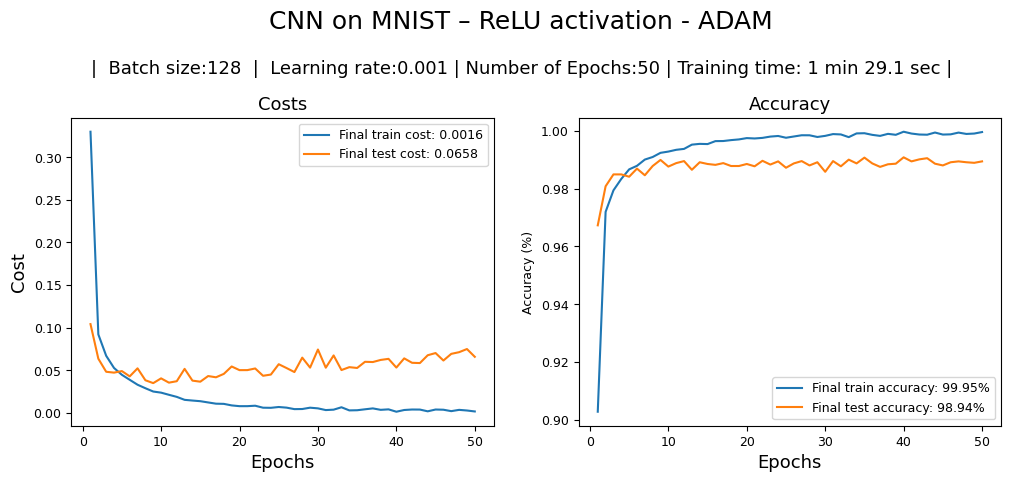

In [ ]:
training_curve_plot(
    title          = "CNN on MNIST – ReLU activation - ADAM",
    train_costs    = train_costs,
    test_costs     = test_costs,
    train_accuracy = train_accuracy,
    test_accuracy  = test_accuracy,
    batch_size     = batch_size,
    learning_rate  = learning_rate,
    num_epochs     = num_epochs,
    elapsed        = elapsed
)

# Optional: save the figure
# plt.savefig("cnn_mnist_learning_curves.png", dpi=150, bbox_inches="tight")

Layer-by-layer (weights + biases):

Conv1: (1 × 3 × 3 × 8) + 8 = 72 + 8 = 80
Conv2: (8 × 3 × 3 × 16) + 16 = 1 152 + 16 = 1 168
Conv3: (16 × 3 × 3 × 32) + 32 = 4 608 + 32 = 4 640
FC: (32 × 7 × 7 × 10) + 10 = 15 680 + 10 = 15 690

Total trainable parameters: 21 578

Comparison to the previous Fully connected network (784→128→64→10):
For a linear layer (fully-connected) from in_features to out_features:

Weights: A matrix of size in_features × out_features = in_features * out_features parameters.
Biases: A vector of size out_features = out_features parameters.
Total per layer: Weights + biases.

Your network has three linear layers (activations like ReLU don't add parameters):

Layer 1: 784 (input) → 128 (hidden1)
Weights: 784 * 128 = 100,352
Biases: 128
Subtotal: 100,480

Layer 2: 128 → 64 (hidden2)
Weights: 128 * 64 = 8,192
Biases: 64
Subtotal: 8,256

Layer 3: 64 → 10 (output)
Weights: 64 * 10 = 640
Biases: 10
Subtotal: 650


Grand total trainable parameters: 100,480 + 8,256 + 650 = 109,386

Total params ≈ 109 322 (roughly 5× more than this CNN)
CNN has far fewer parameters because convolutions reuse the same kernel weights across all spatial positions (weight sharing). The parameter count depends only on kernel size + input/output channels (not on 28×28 spatial size — as the hint says). This is why CNNs are more efficient and generalize better on images.

**EXERCISE -- 4**

In [ ]:
X_train, Y_train, X_test, Y_test = load_mnist()
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_test_cnn = X_test.reshape(-1, 1, 28, 28)

train_dataset = TensorDataset(torch.tensor(X_train_cnn, dtype=torch.float32),
                              torch.tensor(np.argmax(Y_train, axis=1), dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_cnn, dtype=torch.float32),
                             torch.tensor(np.argmax(Y_test, axis=1), dtype=torch.long))

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
#@title Plain Deeper CNN (Without Residuals – to Show Degradation)

class PlainDeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Initial conv (to 8 channels)
        self.conv_init = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)

        # Layer 1: extra conv for depth (8→8)
        self.conv1_extra = nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1)

        # Downsample to 16
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1)
        self.conv2_extra = nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1)

        # Downsample to 32
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3_extra = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)

        # FC
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.conv_init(x))

        # Layer 1 (8 ch)
        x = F.relu(self.conv1_extra(x))

        # Layer 2 (16 ch)
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv2_extra(x))

        # Layer 3 (32 ch)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv3_extra(x))

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Instantiate
model_plain_deep = PlainDeepCNN().to(device)


In [ ]:
#@title Residual CNN (With Skip Connections)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)

        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        out = F.relu(self.conv1(x))
        out = self.conv2(out)
        out += self.skip(x)  # Skip connection
        out = F.relu(out)
        return out

class ResidualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Initial conv to 8
        self.conv_init = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)

        # Layer 1: residual block (8→8, stride=1)
        self.layer1 = ResidualBlock(8, 8, stride=1)

        # Downsample to 16 (stride=2 in block)
        self.layer2 = ResidualBlock(8, 16, stride=2)

        # Downsample to 32
        self.layer3 = ResidualBlock(16, 32, stride=2)

        # FC
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.conv_init(x))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Instantiate
model_res = ResidualCNN().to(device)


In [ ]:
#@title Deeper Residual CNN (Add Extra Blocks for Depth)

class DeeperResidualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Initial to 8
        self.conv_init = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)

        # Layer 1: two residual blocks (8→8)
        self.layer1_block1 = ResidualBlock(8, 8, stride=1)
        self.layer1_block2 = ResidualBlock(8, 8, stride=1)

        # Down to 16
        self.layer2_block1 = ResidualBlock(8, 16, stride=2)
        self.layer2_block2 = ResidualBlock(16, 16, stride=1)

        # Down to 32
        self.layer3_block1 = ResidualBlock(16, 32, stride=2)
        self.layer3_block2 = ResidualBlock(32, 32, stride=1)

        # FC
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.conv_init(x))

        # Layer 1
        x = self.layer1_block1(x)
        x = self.layer1_block2(x)

        # Layer 2
        x = self.layer2_block1(x)
        x = self.layer2_block2(x)

        # Layer 3
        x = self.layer3_block1(x)
        x = self.layer3_block2(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Instantiate
model_deep_res = DeeperResidualCNN().to(device)


In [ ]:
#@title Training Function (Reusable for All Models)

def train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=50):
    train_costs = []
    test_costs = []
    train_accuracy = []
    test_accuracy = []

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        batch_accs = []

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            _, preds = torch.max(outputs, 1)
            acc = (preds == batch_y).float().mean().item()
            batch_accs.append(acc)

        train_costs.append(np.mean(batch_losses))
        train_accuracy.append(np.mean(batch_accs))

        model.eval()
        test_loss = 0
        test_correct = 0
        with torch.no_grad():
            for test_x, test_y in test_loader:
                test_x, test_y = test_x.to(device), test_y.to(device)
                outputs = model(test_x)
                loss = criterion(outputs, test_y)
                test_loss += loss.item() * test_x.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += (preds == test_y).sum().item()

        test_costs.append(test_loss / len(test_loader.dataset))
        test_accuracy.append(test_correct / len(test_loader.dataset))

        print(f"Epoch {epoch+1}/{num_epochs}: Train Cost {train_costs[-1]:.4f}, Train Acc {train_accuracy[-1]:.4f}, Test Cost {test_costs[-1]:.4f}, Test Acc {test_accuracy[-1]:.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed:.2f} seconds")

    return train_costs, test_costs, train_accuracy, test_accuracy, elapsed

Epoch 1/50: Train Cost 0.3046, Train Acc 0.9044, Test Cost 0.0741, Test Acc 0.9762
Epoch 2/50: Train Cost 0.0719, Train Acc 0.9784, Test Cost 0.0568, Test Acc 0.9827
Epoch 3/50: Train Cost 0.0520, Train Acc 0.9840, Test Cost 0.0433, Test Acc 0.9863
Epoch 4/50: Train Cost 0.0403, Train Acc 0.9876, Test Cost 0.0453, Test Acc 0.9856
Epoch 5/50: Train Cost 0.0340, Train Acc 0.9891, Test Cost 0.0347, Test Acc 0.9891
Epoch 6/50: Train Cost 0.0266, Train Acc 0.9912, Test Cost 0.0444, Test Acc 0.9867
Epoch 7/50: Train Cost 0.0239, Train Acc 0.9920, Test Cost 0.0492, Test Acc 0.9850
Epoch 8/50: Train Cost 0.0208, Train Acc 0.9929, Test Cost 0.0478, Test Acc 0.9878
Epoch 9/50: Train Cost 0.0171, Train Acc 0.9945, Test Cost 0.0442, Test Acc 0.9865
Epoch 10/50: Train Cost 0.0170, Train Acc 0.9945, Test Cost 0.0392, Test Acc 0.9874
Epoch 11/50: Train Cost 0.0140, Train Acc 0.9956, Test Cost 0.0371, Test Acc 0.9907
Epoch 12/50: Train Cost 0.0124, Train Acc 0.9958, Test Cost 0.0380, Test Acc 0.9892
E

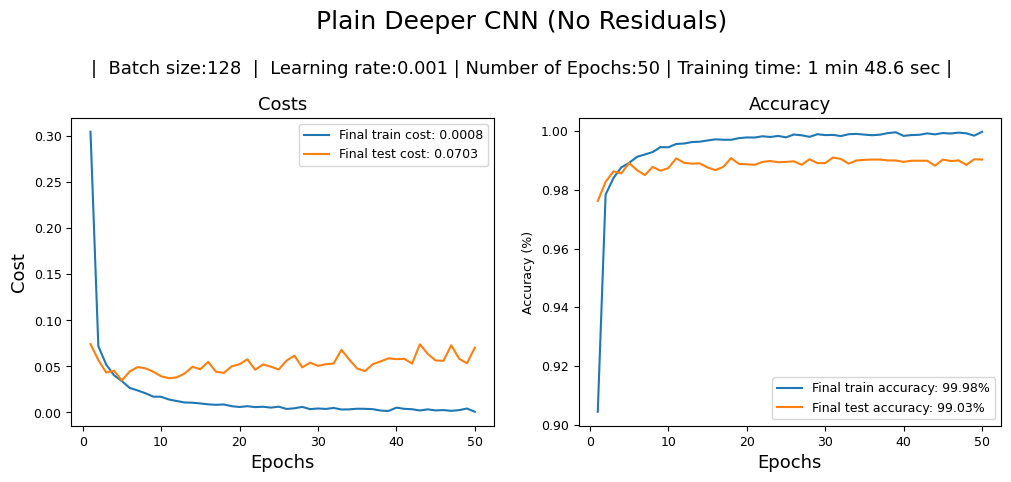

In [ ]:
#@title Train and Plot Plain Deeper Model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_plain_deep.parameters(), lr=0.001)  # Adam from Exercise 3

train_costs, test_costs, train_acc, test_acc, elapsed = train_model(
    model_plain_deep, optimizer, criterion, train_loader, test_loader, num_epochs=50
)

training_curve_plot(
    title="Plain Deeper CNN (No Residuals)",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_acc,
    test_accuracy=test_acc,
    batch_size=batch_size,
    learning_rate=0.001,
    num_epochs=50,
    elapsed=elapsed
)

Epoch 1/50: Train Cost 0.3059, Train Acc 0.9099, Test Cost 0.0876, Test Acc 0.9715
Epoch 2/50: Train Cost 0.0766, Train Acc 0.9771, Test Cost 0.0585, Test Acc 0.9820
Epoch 3/50: Train Cost 0.0537, Train Acc 0.9835, Test Cost 0.0480, Test Acc 0.9843
Epoch 4/50: Train Cost 0.0403, Train Acc 0.9876, Test Cost 0.0469, Test Acc 0.9850
Epoch 5/50: Train Cost 0.0316, Train Acc 0.9900, Test Cost 0.0402, Test Acc 0.9879
Epoch 6/50: Train Cost 0.0270, Train Acc 0.9911, Test Cost 0.0396, Test Acc 0.9866
Epoch 7/50: Train Cost 0.0223, Train Acc 0.9926, Test Cost 0.0406, Test Acc 0.9883
Epoch 8/50: Train Cost 0.0185, Train Acc 0.9937, Test Cost 0.0562, Test Acc 0.9854
Epoch 9/50: Train Cost 0.0173, Train Acc 0.9941, Test Cost 0.0396, Test Acc 0.9884
Epoch 10/50: Train Cost 0.0147, Train Acc 0.9951, Test Cost 0.0422, Test Acc 0.9888
Epoch 11/50: Train Cost 0.0136, Train Acc 0.9954, Test Cost 0.0415, Test Acc 0.9885
Epoch 12/50: Train Cost 0.0110, Train Acc 0.9963, Test Cost 0.0405, Test Acc 0.9896
E

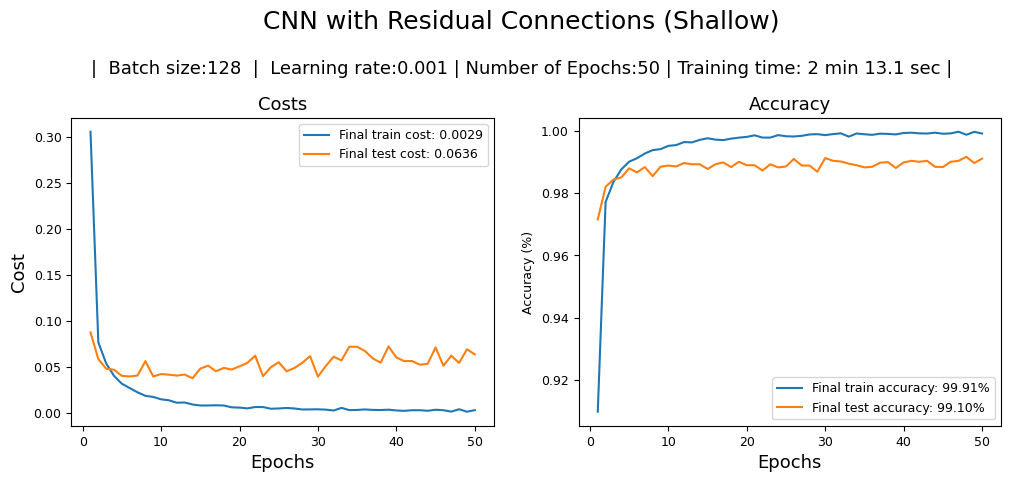

In [ ]:
#@title Train and Plot Residual Model (Shallow)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_res.parameters(), lr=0.001)

train_costs, test_costs, train_acc, test_acc, elapsed = train_model(
    model_res, optimizer, criterion, train_loader, test_loader, num_epochs=50
)

training_curve_plot(
    title="CNN with Residual Connections (Shallow)",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_acc,
    test_accuracy=test_acc,
    batch_size=batch_size,
    learning_rate=0.001,
    num_epochs=50,
    elapsed=elapsed
)

Epoch 1/50: Train Cost 0.2342, Train Acc 0.9321, Test Cost 0.0779, Test Acc 0.9771
Epoch 2/50: Train Cost 0.0548, Train Acc 0.9829, Test Cost 0.0496, Test Acc 0.9847
Epoch 3/50: Train Cost 0.0374, Train Acc 0.9885, Test Cost 0.0380, Test Acc 0.9885
Epoch 4/50: Train Cost 0.0284, Train Acc 0.9910, Test Cost 0.0394, Test Acc 0.9877
Epoch 5/50: Train Cost 0.0237, Train Acc 0.9920, Test Cost 0.0346, Test Acc 0.9893
Epoch 6/50: Train Cost 0.0191, Train Acc 0.9940, Test Cost 0.0356, Test Acc 0.9904
Epoch 7/50: Train Cost 0.0163, Train Acc 0.9944, Test Cost 0.0465, Test Acc 0.9873
Epoch 8/50: Train Cost 0.0140, Train Acc 0.9954, Test Cost 0.0297, Test Acc 0.9916
Epoch 9/50: Train Cost 0.0129, Train Acc 0.9959, Test Cost 0.0559, Test Acc 0.9858
Epoch 10/50: Train Cost 0.0125, Train Acc 0.9958, Test Cost 0.0311, Test Acc 0.9914
Epoch 11/50: Train Cost 0.0108, Train Acc 0.9965, Test Cost 0.0381, Test Acc 0.9903
Epoch 12/50: Train Cost 0.0093, Train Acc 0.9970, Test Cost 0.0427, Test Acc 0.9896
E

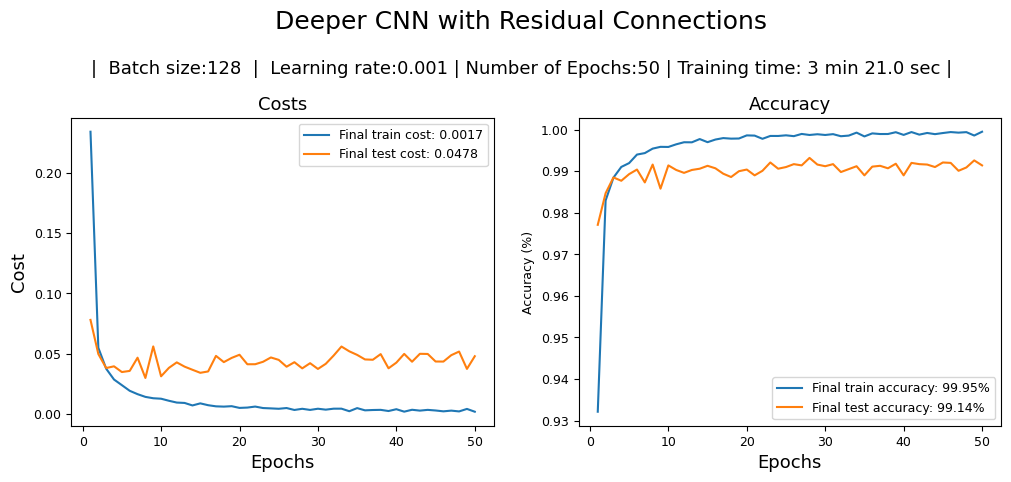

In [ ]:
#@title Train and Plot Deeper Residual Model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_deep_res.parameters(), lr=0.001)

train_costs, test_costs, train_acc, test_acc, elapsed = train_model(
    model_deep_res, optimizer, criterion, train_loader, test_loader, num_epochs=50
)

training_curve_plot(
    title="Deeper CNN with Residual Connections",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_acc,
    test_accuracy=test_acc,
    batch_size=batch_size,
    learning_rate=0.001,
    num_epochs=50,
    elapsed=elapsed
)

In [ ]:
#@title Residual Block with BN/Dropout Options

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_bn=False, dropout_p=0.0):
        super().__init__()
        self.use_bn = use_bn
        self.dropout_p = dropout_p

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.dropout1 = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=not use_bn)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.dropout2 = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()

        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=not use_bn),
                nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.dropout2(out)

        out += self.skip(x)
        out = F.relu(out)
        return out

In [ ]:
#@title Residual CNN with BN or Dropout

class RegularizedResidualCNN(nn.Module):
    def __init__(self, use_bn=False, dropout_p=0.0):
        super().__init__()
        # Initial conv to 8
        self.conv_init = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1, bias=not use_bn)
        self.bn_init = nn.BatchNorm2d(8) if use_bn else nn.Identity()

        # Layer 1: 8→8, stride=1
        self.layer1 = ResidualBlock(8, 8, stride=1, use_bn=use_bn, dropout_p=dropout_p)

        # Layer 2: 8→16, stride=2
        self.layer2 = ResidualBlock(8, 16, stride=2, use_bn=use_bn, dropout_p=dropout_p)

        # Layer 3: 16→32, stride=2
        self.layer3 = ResidualBlock(16, 32, stride=2, use_bn=use_bn, dropout_p=dropout_p)

        # FC with optional dropout
        self.dropout_fc = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv_init(x)
        x = self.bn_init(x)
        x = F.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = self.fc(x)
        return x

# BN variant
model_bn = RegularizedResidualCNN(use_bn=True, dropout_p=0.0).to(device)
# Dropout variant
model_dropout = RegularizedResidualCNN(use_bn=False, dropout_p=0.5).to(device)

Epoch 1/50: Train Cost 0.1646, Train Acc 0.9493, Test Cost 0.0389, Test Acc 0.9868
Epoch 2/50: Train Cost 0.0424, Train Acc 0.9866, Test Cost 0.0378, Test Acc 0.9884
Epoch 3/50: Train Cost 0.0292, Train Acc 0.9907, Test Cost 0.0461, Test Acc 0.9865
Epoch 4/50: Train Cost 0.0234, Train Acc 0.9927, Test Cost 0.0318, Test Acc 0.9898
Epoch 5/50: Train Cost 0.0197, Train Acc 0.9937, Test Cost 0.0305, Test Acc 0.9891
Epoch 6/50: Train Cost 0.0140, Train Acc 0.9953, Test Cost 0.0298, Test Acc 0.9905
Epoch 7/50: Train Cost 0.0133, Train Acc 0.9956, Test Cost 0.0355, Test Acc 0.9897
Epoch 8/50: Train Cost 0.0107, Train Acc 0.9967, Test Cost 0.0355, Test Acc 0.9895
Epoch 9/50: Train Cost 0.0074, Train Acc 0.9976, Test Cost 0.0371, Test Acc 0.9891
Epoch 10/50: Train Cost 0.0089, Train Acc 0.9972, Test Cost 0.0398, Test Acc 0.9899
Epoch 11/50: Train Cost 0.0080, Train Acc 0.9974, Test Cost 0.0431, Test Acc 0.9886
Epoch 12/50: Train Cost 0.0064, Train Acc 0.9979, Test Cost 0.0364, Test Acc 0.9913
E

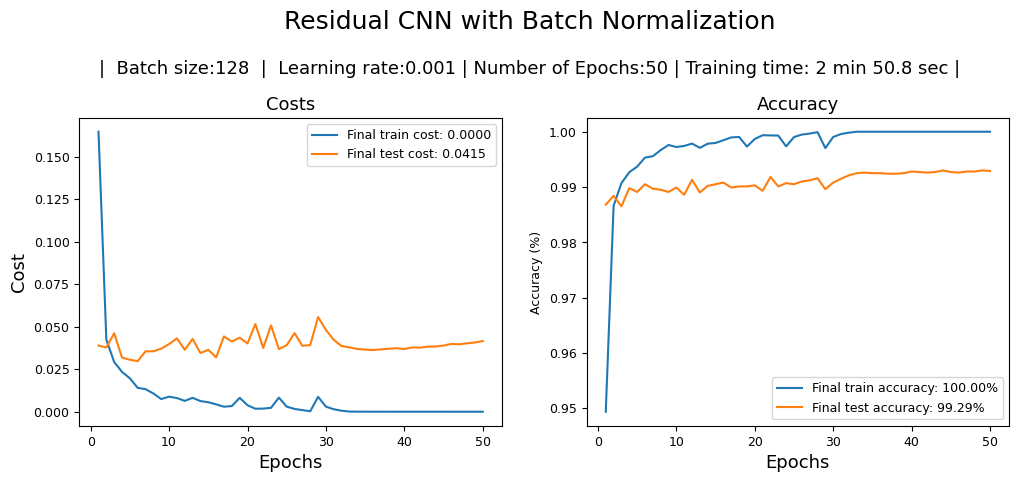

In [ ]:
#@title Train BN Variant

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bn.parameters(), lr=0.001)  # Higher lr OK with BN

train_costs, test_costs, train_acc, test_acc, elapsed = train_model(
    model_bn, optimizer, criterion, train_loader, test_loader, num_epochs=50
)

training_curve_plot(
    title="Residual CNN with Batch Normalization",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_acc,
    test_accuracy=test_acc,
    batch_size=batch_size,
    learning_rate=0.001,
    num_epochs=50,
    elapsed=elapsed
)

Epoch 1/50: Train Cost 0.6100, Train Acc 0.7994, Test Cost 0.1451, Test Acc 0.9542
Epoch 2/50: Train Cost 0.2098, Train Acc 0.9374, Test Cost 0.0941, Test Acc 0.9697
Epoch 3/50: Train Cost 0.1640, Train Acc 0.9495, Test Cost 0.0745, Test Acc 0.9753
Epoch 4/50: Train Cost 0.1464, Train Acc 0.9551, Test Cost 0.0682, Test Acc 0.9758
Epoch 5/50: Train Cost 0.1311, Train Acc 0.9594, Test Cost 0.0589, Test Acc 0.9810
Epoch 6/50: Train Cost 0.1210, Train Acc 0.9624, Test Cost 0.0515, Test Acc 0.9826
Epoch 7/50: Train Cost 0.1157, Train Acc 0.9636, Test Cost 0.0501, Test Acc 0.9826
Epoch 8/50: Train Cost 0.1097, Train Acc 0.9670, Test Cost 0.0495, Test Acc 0.9835
Epoch 9/50: Train Cost 0.1053, Train Acc 0.9671, Test Cost 0.0507, Test Acc 0.9836
Epoch 10/50: Train Cost 0.1054, Train Acc 0.9675, Test Cost 0.0477, Test Acc 0.9846
Epoch 11/50: Train Cost 0.1001, Train Acc 0.9693, Test Cost 0.0496, Test Acc 0.9836
Epoch 12/50: Train Cost 0.0961, Train Acc 0.9704, Test Cost 0.0456, Test Acc 0.9849
E

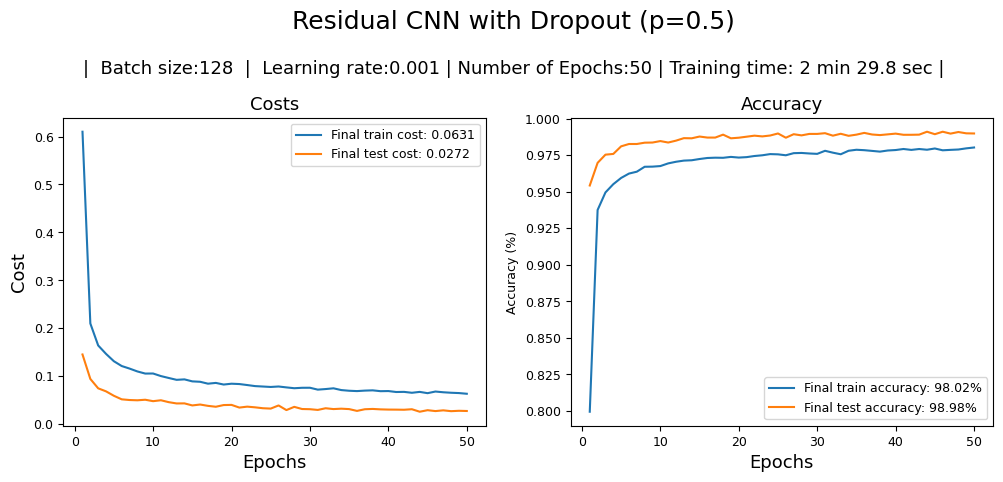

In [ ]:
#@title Train Dropout Variant

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropout.parameters(), lr=0.001)

train_costs, test_costs, train_acc, test_acc, elapsed = train_model(
    model_dropout, optimizer, criterion, train_loader, test_loader, num_epochs=50
)

training_curve_plot(
    title="Residual CNN with Dropout (p=0.5)",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_acc,
    test_accuracy=test_acc,
    batch_size=batch_size,
    learning_rate=0.001,
    num_epochs=50,
    elapsed=elapsed
)

In [ ]:
def plot_confusion_matrix(y_labels, y_preds):
    class_names = np.arange(10)  # MNIST labels 0-9
    cm = confusion_matrix(y_labels, y_preds).astype(np.float64)

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap='coolwarm')
    plt.title("Confusion Matrix")
    plt.colorbar(shrink=0.75, fraction=0.05)

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.tight_layout()
    plt.show()

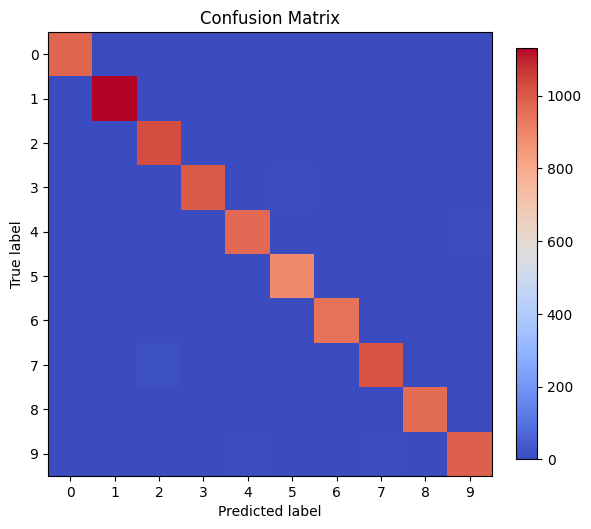

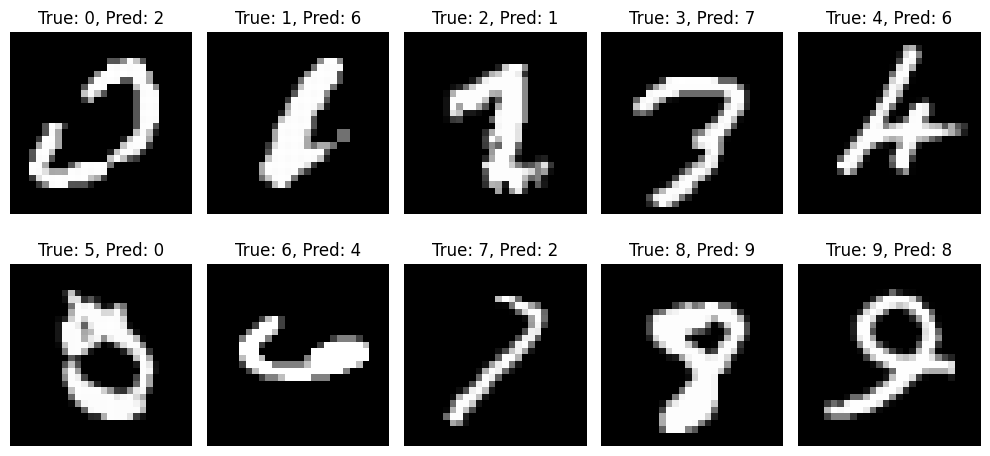

In [ ]:
#@title Confusion Matrix and Misclassifications for Best Model

# Assume model_bn is best; change to model_dropout if not
best_model = model_dropout  # or model_bn

best_model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_images.extend(images.cpu().numpy())

# Confusion matrix
plot_confusion_matrix(all_labels, all_preds)

# Misclassifications: Find 10 wrong ones (try one per class)
misclassified = np.where(np.array(all_preds) != np.array(all_labels))[0]
unique_classes = []
selected = []

for idx in misclassified:
    true_label = all_labels[idx]
    if true_label not in unique_classes:
        unique_classes.append(true_label)
        selected.append(idx)
    if len(selected) == 10:
        break

# Plot 10 misclassified images
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
axs = axs.ravel()

for i, idx in enumerate(selected):
    img = all_images[idx].squeeze()
    true = all_labels[idx]
    pred = all_preds[idx]
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f"True: {true}, Pred: {pred}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()